# Pooling Problem with Nonlinear and Setup Costs
[![pooling.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/pooling/pooling.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/pooling/pooling.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/pooling/pooling.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/pooling/pooling.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/pooling/pooling.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/pooling/pooling.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/glebbelov/nonlinear/pooling/pooling.ipynb)](https://ampl.com)

Description: pooling problem with extra nonlinear and setup costs, solved by Knitro with MP2NL

Tags: AMPLPY, pooling, minimum-cost flow, blending, Knitro, MP2NL, nonlinear, setup costs, semi-continuous

Notebook author: Gleb Belov <<gleb@ampl.com>>

Reference:

1. [Milk pooling and blending](https://ampl.com/mo-book/notebooks/05/milk-pooling.html#). Hands-on optimization with AMPL in Python.
2. [Standard pooling problem in Gurobi](https://www.gurobi.com/jupyter_models/standard-pooling-problem-in-gurobi/), accessed March 12, 2026.
3. [MP2NL meta-driver](https://mp.ampl.com/modeling-tools.html#meta-driver-mp2nl).

In [1]:
# Install dependencies
%pip install -q amplpy pandas seaborn networkx

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["knitro", "mp2nl", "gurobi"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

---
## Motivation

The pooling problem is a challenging problem in the petrochemical refining, wastewater treatment and mining industries. This problem can be regarded as a generalization of the minimum-cost flow problem and the blending problem. It is indeed important because of the significant savings it can generate, so it comes at no surprise that it has been studied extensively.

We take the so-called Q-formulation as the basic model. We solve the standard case first, then add nonlinearities and discrete setup costs.

## The Q-formulation in AMPL

Use `%%ampl_eval` to evaluate AMPL commands and declarations

In [3]:
%%ampl_eval
# AMPL Model for the Standard Pooling Problem (Q-Formulation)

# Sets
set SOURCES;
set POOLS;
set TARGETS;
set ATTRS;

# Edges for flow variables (defined dynamically based on data)
set S2T within {SOURCES, TARGETS};
set S2P within {SOURCES, POOLS};
set P2T within {POOLS, TARGETS};

# Parameters
param cost {SOURCES};
param supply {SOURCES};
param content {SOURCES, ATTRS};

param price {TARGETS};
param demand {TARGETS};
param min_tol {TARGETS, ATTRS};
param max_tol {TARGETS, ATTRS};

param cap {POOLS};

# Variables
var flow_s2t {(s,t) in S2T} >= 0 <= supply[s];  # Flow from source to target
var flow_p2t {(p,t) in P2T} >= 0 <= cap[p];  # Flow from pool to target
var prop_s2p {S2P} >= 0, <= 1; # Proportion from source to pool

# Defined variables
# They are essentially macros for readability and presolve
var pool_outflow {p in POOLS} =
    sum {t in TARGETS: (p,t) in P2T} flow_p2t[p,t];
var source_pool_flow {(s,p) in S2P} =   # flow_s2p: implicit
    prop_s2p[s,p] * pool_outflow[p];
var source_outflow {s in SOURCES} =
    sum {t in TARGETS: (s,t) in S2T} flow_s2t[s,t] +
    sum {p in POOLS: (s,p) in S2P} source_pool_flow[s, p];
var target_inflow {t in TARGETS} =
    sum {s in SOURCES: (s,t) in S2T} flow_s2t[s,t] +
    sum {p in POOLS: (p,t) in P2T} flow_p2t[p,t];
var target_attr_inflow {t in TARGETS, attr in ATTRS} =
    sum {s in SOURCES: (s,t) in S2T} content[s,attr] * flow_s2t[s,t] +
    sum {p in POOLS: (p,t) in P2T}
        flow_p2t[p,t] *
        sum {s in SOURCES: (s,p) in S2P} content[s,attr] * prop_s2p[s,p];

# Objective Function: Maximize Total Profit
maximize TotalProfit:
  sum {t in TARGETS} price[t] * target_inflow[t]
  - sum {s in SOURCES} cost[s] * source_outflow[s];

# Constraints

# 1. Source capacity
subject to Source_capacity {s in SOURCES}:
  source_outflow[s] <= supply[s];

# 2. Pool capacity
subject to Pool_capacity {p in POOLS}:
  pool_outflow[p] <= cap[p];

# 3. Target demand
subject to Target_demand {t in TARGETS}:
  target_inflow[t] >= demand[t];

# 4. Pool inflow (sum of proportions for each pool must be 1)
subject to Pool_inflow {p in POOLS}:
  sum {s in SOURCES: (s,p) in S2P} prop_s2p[s,p] = 1;

# 5.1 Target (min) tolerances
subject to Target_min_tolerances {t in TARGETS, attr in ATTRS}:
  target_attr_inflow[t, attr] >= min_tol[t,attr] * target_inflow[t];

# 5.2 Target (max) tolerances
subject to Target_max_tolerances {t in TARGETS, attr in ATTRS}:
  target_attr_inflow[t, attr] <= max_tol[t,attr] * target_inflow[t];

## Random instance data

We generate the insatnce parameters randomly.

In [4]:
import random
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_pooling_data(num_sources=3, num_pools=2, num_targets=3, num_attrs=4,
                          source_cost_range=(10, 50), source_supply_range=(500, 2000),
                          target_price_range=(100, 300), target_demand_range=(100, 1000),
                          pool_cap_range=(500, 2000),
                          s2t_density=0.5, s2p_density=0.8, p2t_density=0.8,
                          content_deviation_percent=0.05, # Max % deviation for source content from ref
                          tolerance_deviation_percent=0.10, # Max % deviation for min_tol from ref
                          tolerance_gap_percent=0.05): # Average % gap for max_tol above min_tol

    sources = [f"s{i+1}" for i in range(num_sources)]
    pools = [f"p{i+1}" for i in range(num_pools)]
    targets = [f"t{i+1}" for i in range(num_targets)]
    attrs = [f"attr{i+1}" for i in range(num_attrs)]

    # Generate diverse reference ranges for attributes
    # This mimics having some low-value attributes (like 'den') and some high-value ones (like 'roz')
    attr_range_templates = [
        {'ref_range': (0.5, 1.0)},   # Low values
        {'ref_range': (2.0, 5.0)},   # Medium-low values
        {'ref_range': (50.0, 70.0)}, # Medium-high values
        {'ref_range': (90.0, 110.0)} # High values
    ]
    
    reference_attr_configs = {}
    for i, attr in enumerate(attrs):
        # Assign a template in a round-robin fashion or randomly
        template = random.choice(attr_range_templates)
        reference_attr_configs[attr] = template

    cost = {s: random.uniform(*source_cost_range) for s in sources}
    supply = {s: random.uniform(*source_supply_range) for s in sources}
    price = {t: random.uniform(*target_price_range) for t in targets}
    demand = {t: random.uniform(*target_demand_range) for t in targets}
    cap = {p: random.uniform(*pool_cap_range) for p in pools}

    # 1. Generate reference content for each attribute
    reference_content_values = {
        attr: random.uniform(*config['ref_range'])
        for attr, config in reference_attr_configs.items()
    }

    # 2. Generate source contents with deviation from reference
    content = {}
    for s in sources:
        for a in attrs:
            ref_val = reference_content_values[a]
            dev_factor = random.uniform(1 - content_deviation_percent, 1 + content_deviation_percent)
            content[s, a] = max(0.0, ref_val * dev_factor) # Ensure non-negative content

    # 3. Generate target tolerances with deviation from reference and controlled gap
    min_tol = {}
    max_tol = {}
    for t in targets:
        for a in attrs:
            ref_val = reference_content_values[a]

            # Min tolerance deviation from reference
            dev_min_factor = random.uniform(1 - tolerance_deviation_percent, 1)
            min_t = max(0.0, ref_val * dev_min_factor)

            # Max tolerance based on min_t and the gap parameter
            gap_factor = random.uniform(1 + tolerance_gap_percent * 0.8, 1 + tolerance_gap_percent * 1.2)
            max_t = min_t * gap_factor
            max_t = max(min_t, max_t) # Ensure max_t is always >= min_t

            min_tol[t, a] = min_t
            max_tol[t, a] = max_t

    s2t = [(s, t) for s in sources for t in targets if random.random() < s2t_density]
    s2p = [(s, p) for s in sources for p in pools if random.random() < s2p_density]
    p2t = [(p, t) for p in pools for t in targets if random.random() < p2t_density]

    return {
        "sources": sources,
        "pools": pools,
        "targets": targets,
        "attrs": attrs,
        "cost": cost,
        "supply": supply,
        "content": content,
        "price": price,
        "demand": demand,
        "min_tol": min_tol,
        "max_tol": max_tol,
        "cap": cap,
        "s2t": s2t,
        "s2p": s2p,
        "p2t": p2t,
    }

In [5]:
# Generate random data with customizable parameters
# You can change these values to generate different problem instances
num_sources_param = 23
num_pools_param = 12
num_targets_param = 16
num_attrs_param = 5

random.seed(42)        # Same seed for reproducibility

data = generate_pooling_data(
    num_sources=num_sources_param,
    num_pools=num_pools_param,
    num_targets=num_targets_param,
    num_attrs=num_attrs_param, # Pass the number of attributes
    s2t_density=0.1, s2p_density=0.2, p2t_density=0.4,
    content_deviation_percent=0.05,  # Source content varies by up to +/- 5% from reference
    tolerance_deviation_percent=0.005, # Min tolerance varies by up to +/- 10% from reference
    tolerance_gap_percent=0.015       # Max tolerance is avg 5% above min tolerance (with variation)
)

### Data statistics

In [6]:
# Display data statistics
print("\n--- Data Statistics ---")
print(f"Number of Sources: {len(data['sources'])}")
print(f"Number of Pools: {len(data['pools'])}")
print(f"Number of Targets: {len(data['targets'])}")
print(f"Number of Attributes: {len(data['attrs'])}")

print("\nCost per Source (Min/Max):", round(min(data['cost'].values()),2), "/", round(max(data['cost'].values()),2))
print("Supply per Source (Min/Max):", round(min(data['supply'].values()),2), "/", round(max(data['supply'].values()),2))
print("Price per Target (Min/Max):", round(min(data['price'].values()),2), "/", round(max(data['price'].values()),2))
print("Demand per Target (Min/Max):", round(min(data['demand'].values()),2), "/", round(max(data['demand'].values()),2))
print("Capacity per Pool (Min/Max):", round(min(data['cap'].values()),2), "/", round(max(data['cap'].values()),2))

print(f"Number of Source-to-Target edges: {len(data['s2t'])}")
print(f"Number of Source-to-Pool edges: {len(data['s2p'])}")
print(f"Number of Pool-to-Target edges: {len(data['p2t'])}")


--- Data Statistics ---
Number of Sources: 23
Number of Pools: 12
Number of Targets: 16
Number of Attributes: 5

Cost per Source (Min/Max): 11.27 / 44.77
Supply per Source (Min/Max): 565.18 / 1977.83
Price per Target (Min/Max): 114.28 / 285.08
Demand per Target (Min/Max): 150.34 / 921.82
Capacity per Pool (Min/Max): 707.5 / 1995.99
Number of Source-to-Target edges: 27
Number of Source-to-Pool edges: 53
Number of Pool-to-Target edges: 76


### Contents and tolerances

In [7]:
print("\n--- Content of Attributes in Sources ---")
content_df = pd.Series(data['content']).unstack()
content_df.index.name = 'Source'
content_df.columns.name = 'Attribute'
display(content_df)

print("\n--- Minimum Tolerances for Attributes in Targets ---")
min_tol_df = pd.Series(data['min_tol']).unstack()
min_tol_df.index.name = 'Target'
min_tol_df.columns.name = 'Attribute'
display(min_tol_df)

print("\n--- Maximum Tolerances for Attributes in Targets ---")
max_tol_df = pd.Series(data['max_tol']).unstack()
max_tol_df.index.name = 'Target'
max_tol_df.columns.name = 'Attribute'
display(max_tol_df)


--- Content of Attributes in Sources ---


Attribute,attr1,attr2,attr3,attr4,attr5
Source,,,,,
s1,0.802453,0.723017,63.034043,3.272937,2.860222
s10,0.806713,0.724535,64.573505,3.491046,2.806537
s11,0.815202,0.685390,62.980816,3.361060,2.864306
s12,0.794332,0.674929,59.218314,3.241103,2.769094
s13,0.805264,0.658262,63.204673,3.253984,2.635094
s14,0.760802,0.680643,62.005420,3.328740,2.750225
s15,0.801336,0.707848,64.285399,3.430093,2.683458
s16,0.796047,0.685949,59.405924,3.458270,2.714112
s17,0.791109,0.717575,59.157296,3.456388,2.794504



--- Minimum Tolerances for Attributes in Targets ---


Attribute,attr1,attr2,attr3,attr4,attr5
Target,,,,,
t1,0.796994,0.691634,61.758848,3.390834,2.750603
t10,0.796419,0.689067,61.897053,3.387808,2.749864
t11,0.795625,0.691950,61.840210,3.391158,2.751487
t12,0.795859,0.692122,61.735642,3.399640,2.742663
t13,0.795740,0.690551,61.892522,3.401095,2.743541
t14,0.795804,0.689162,61.716891,3.398695,2.745031
t15,0.797714,0.690932,61.620024,3.393013,2.746481
t16,0.794675,0.689580,61.743178,3.400856,2.753420
t2,0.795465,0.690572,61.772610,3.395773,2.741415



--- Maximum Tolerances for Attributes in Targets ---


Attribute,attr1,attr2,attr3,attr4,attr5
Target,,,,,
t1,0.810051,0.702680,62.570321,3.432714,2.784616
t10,0.808029,0.698843,63.000875,3.435735,2.793866
t11,0.807845,0.704296,62.925789,3.435159,2.787427
t12,0.806266,0.703677,62.724612,3.445498,2.787116
t13,0.805474,0.699665,62.765080,3.459689,2.787329
t14,0.806684,0.700630,62.646127,3.456683,2.778426
t15,0.808537,0.703300,62.580028,3.449739,2.795658
t16,0.808500,0.698038,62.676706,3.455682,2.798637
t2,0.805250,0.702669,62.534963,3.453868,2.775430


### Data visualization

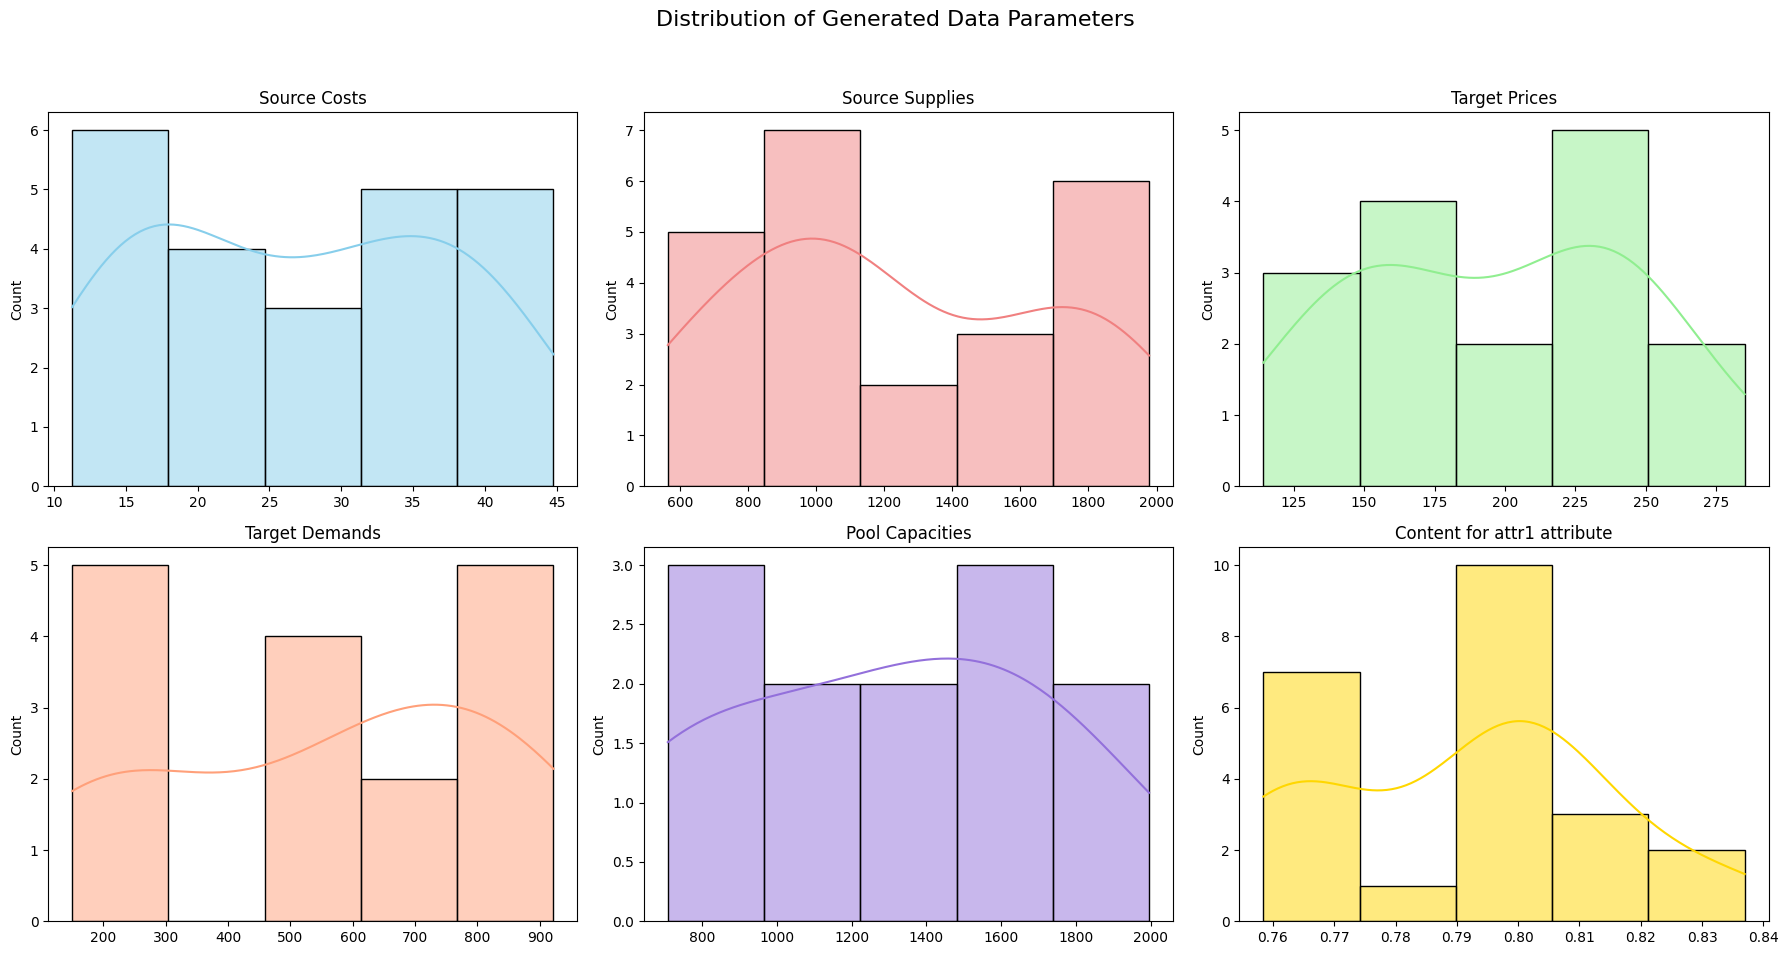

In [8]:
# Data Visualization (Histograms)
# Adjust subplot grid if num_attrs_param is large, or just plot one example
num_plots = min(len(data['attrs']), 6) # Plot up to 6 attribute distributions if many attrs
num_rows = math.ceil(num_plots / 3)
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows))
fig.suptitle('Distribution of Generated Data Parameters', fontsize=16)

# Flatten axes for easier iteration if there are multiple rows
if num_rows > 1: 
    axes = axes.flatten()
else: # Handle case where there's only one row (axes is a 1D array or single object)
    if isinstance(axes, np.ndarray) and axes.ndim == 1:
        pass # already flat
    else:
        axes = [axes] # make it iterable

current_plot_idx = 0

sns.histplot(list(data['cost'].values()), bins=5, kde=True, ax=axes[current_plot_idx], color='skyblue')
axes[current_plot_idx].set_title('Source Costs')
current_plot_idx += 1

sns.histplot(list(data['supply'].values()), bins=5, kde=True, ax=axes[current_plot_idx], color='lightcoral')
axes[current_plot_idx].set_title('Source Supplies')
current_plot_idx += 1

sns.histplot(list(data['price'].values()), bins=5, kde=True, ax=axes[current_plot_idx], color='lightgreen')
axes[current_plot_idx].set_title('Target Prices')
current_plot_idx += 1

sns.histplot(list(data['demand'].values()), bins=5, kde=True, ax=axes[current_plot_idx], color='lightsalmon')
axes[current_plot_idx].set_title('Target Demands')
current_plot_idx += 1

sns.histplot(list(data['cap'].values()), bins=5, kde=True, ax=axes[current_plot_idx], color='mediumpurple')
axes[current_plot_idx].set_title('Pool Capacities')
current_plot_idx += 1

# Plot distribution for one example attribute content
if len(data['attrs']) > 0:
    attr_to_plot = data['attrs'][0]
    attr_contents = [val for (s, a), val in data['content'].items() if a == attr_to_plot]
    sns.histplot(attr_contents, bins=5, kde=True, ax=axes[current_plot_idx], color='gold')
    axes[current_plot_idx].set_title(f'Content for {attr_to_plot} attribute')
    current_plot_idx += 1

# Hide any remaining empty subplots
for i in range(current_plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Network visualization

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_pooling_network(data):
    G = nx.DiGraph()

    # Add Source nodes with supply
    for s in data['sources']:
        G.add_node(s, node_type='source', capacity=data['supply'][s])

    # Add Pool nodes with capacity
    for p in data['pools']:
        G.add_node(p, node_type='pool', capacity=data['cap'][p])

    # Add Target nodes with demand
    for t in data['targets']:
        # Demand is a dictionary, might have multiple attributes. Let's sum for simplicity for visualization.
        total_demand = sum(data['demand'].get(t, 0) for t_key in data['demand'] if t_key == t)
        G.add_node(t, node_type='target', capacity=total_demand)

    # Add edges
    for s, t in data['s2t']:
        G.add_edge(s, t, edge_type='s2t')
    for s, p in data['s2p']:
        G.add_edge(s, p, edge_type='s2p')
    for p, t in data['p2t']:
        G.add_edge(p, t, edge_type='p2t')

    # Define node colors and labels
    node_colors = []
    node_labels = {}
    for node in G.nodes():
        if G.nodes[node]['node_type'] == 'source':
            node_colors.append('skyblue')
            node_labels[node] = f"{node}\nSupply: {G.nodes[node]['capacity']:.0f}"
        elif G.nodes[node]['node_type'] == 'pool':
            node_colors.append('lightgreen')
            node_labels[node] = f"{node}\nCapacity: {G.nodes[node]['capacity']:.0f}"
        else: # target
            node_colors.append('salmon')
            node_labels[node] = f"{node}\nDemand: {G.nodes[node]['capacity']:.0f}"

    plt.figure(figsize=(12, 8))
    
    # Use a layered layout to better visualize the tripartite graph
    pos = {}
    source_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'source']
    pool_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'pool']
    target_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'target']
    
    # Position sources, pools, and targets in distinct columns
    for i, node in enumerate(source_nodes):
        pos[node] = (0, i)
    for i, node in enumerate(pool_nodes):
        pos[node] = (1, i)
    for i, node in enumerate(target_nodes):
        pos[node] = (2, i)

    nx.draw(G, pos, with_labels=False, node_color=node_colors, node_size=3000, alpha=0.9, font_size=8, font_weight='bold')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)
    
    # No explicit arc capacities in the problem formulation, so we'll just show the arcs.
    # If specific capacities were defined for each s2p, s2t, p2t flow, they could be added here.
    
    plt.title('Pooling Problem Network Visualization with Node Capacities/Demands')
    plt.axis('off')
    # plt.tight_layout()
    plt.show()

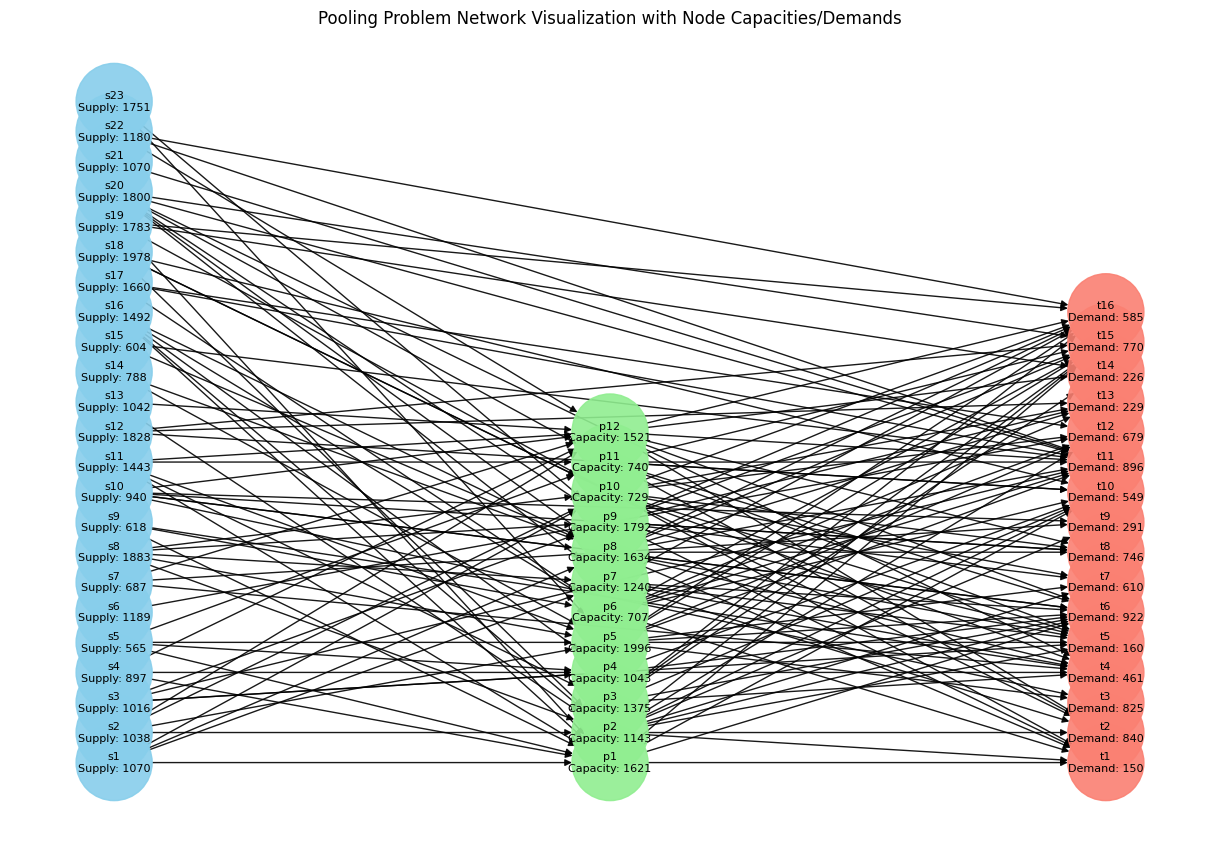

In [10]:
# Call the visualization function with the generated data
visualize_pooling_network(data)

## Load data directly from Python data structures using [amplpy](https://amplpy.readthedocs.io/)

In [11]:
# Set the data
# Sets
ampl.getSet('SOURCES').setValues(data['sources'])
ampl.getSet('POOLS').setValues(data['pools'])
ampl.getSet('TARGETS').setValues(data['targets'])
ampl.getSet('ATTRS').setValues(data['attrs'])

# Edges
ampl.getSet('S2T').setValues(data['s2t'])
ampl.getSet('S2P').setValues(data['s2p'])
ampl.getSet('P2T').setValues(data['p2t'])

# Parameters
ampl.getParameter('cost').setValues(data['cost'])
ampl.getParameter('supply').setValues(data['supply'])
ampl.getParameter('content').setValues(data['content'])

ampl.getParameter('price').setValues(data['price'])
ampl.getParameter('demand').setValues(data['demand'])
ampl.getParameter('min_tol').setValues(data['min_tol'])
ampl.getParameter('max_tol').setValues(data['max_tol'])

ampl.getParameter('cap').setValues(data['cap'])

print("AMPL model loaded and data assigned successfully.")

AMPL model loaded and data assigned successfully.


## Solve the standard model

### Solve with Knitro

In [12]:
ampl.option["solver"] = "knitro"
ampl.option["knitro_options"] = "outlev=1 ms_enable=1"

ampl.snapshot('pooling.run')     # Debugging feature

print("\nSolving the AMPL model...")
ampl.solve()
# ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=30")


Solving the AMPL model...
Artelys Knitro 15.1.0: outlev=1
ms_enable=1

          Commercial License
         Artelys Knitro 15.1.0

Knitro using up to 8 threads.
Knitro presolve eliminated 0 variables and 0 constraints.

concurrent_evals         0
datacheck                0
feastol                  1e-06
feastol_abs              0.001
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
ms_enable                1
opttol                   1e-06
opttol_abs               0.001
outlev                   1

Problem Characteristics                     |           Presolved
-----------------------
Problem type: QCQP
Objective: maximize / quadratic
Number of variables:                    155 |                           155
  bounds:         lower     upper     range |     lower     upper     range
                      0         0       155 |         0         0       155
                             free     fixed |                free     fixed
                   

### Check and display solution

In [13]:
def display_result(ampl):
    # Check solver status
    print(f"AMPL solve result: {ampl.solve_result}, solve code: {ampl.solve_result_num}")
    
    if "solved" in ampl.solve_result or \
            "limit" in ampl.solve_result and 410>ampl.solve_result_num:
        # Retrieve and display results
        # objective_value = ampl.getObjective(next(reversed(ampl.getObjectives()))).value()
        # print(f"\nCurrent objective ({ampl.getObjectives()[-1].getName()}): {objective_value:.2f}")
        ampl.eval('display _objname, _obj;')
    
        print("\n--- Flow from Sources to Targets (flow_s2t) ---")
        flow_s2t_df = ampl.getData('flow_s2t').toPandas().unstack()
        if not flow_s2t_df.empty: # Check if DataFrame is not empty
            df = flow_s2t_df[flow_s2t_df['flow_s2t'] > 1e-6]
            nnz = (df > 1e-6).sum().sum()
            df = df.round(2).replace({np.nan: '-'})
            display(df)
            print(f"Total non-zero values: {nnz}")
        else:
            print("No flow from sources to targets.")

        print("\n--- Flow from Pools to Targets (flow_p2t) ---")
        flow_p2t_df = ampl.getData('flow_p2t').toPandas().unstack()
        if not flow_p2t_df.empty: # Check if DataFrame is not empty
            df = flow_p2t_df[flow_p2t_df['flow_p2t'] > 1e-6]
            nnz = (df > 1e-6).sum().sum()
            df = df.round(2).replace({np.nan: '-'})
            display(df)
            print(f"Total non-zero values: {nnz}")
        else:
            print("No flow from pools to targets.")

        print("\n--- Proportion from Sources to Pools (prop_s2p) ---")
        prop_s2p_df = ampl.getData('prop_s2p').toPandas().unstack()
        if not prop_s2p_df.empty: # Check if DataFrame is not empty
            df = prop_s2p_df[prop_s2p_df['prop_s2p'] > 1e-6]
            nnz = (df > 1e-6).sum().sum()
            df = df.round(2).replace({np.nan: '-'})
            display(df)
            print(f"Total non-zero values: {nnz}")
        else:
            print("No proportion from sources to pools.")

    else:
        print("No optimal or feasible solution found.")

In [14]:
display_result(ampl)

AMPL solve result: solved, solve code: 0
:    _objname      _obj      :=
1   TotalProfit   4233070
;


--- Flow from Sources to Targets (flow_s2t) ---


flow_s2t                                                         \
index1       t1    t10     t11      t12     t13    t14     t15     t16   
index0                                                                   
s10           -      -       -        -       -      -       -       -   
s12           -  72.05       -        -  140.67      -  165.93       -   
s15           -      -  226.84        -       -      -       -       -   
s17           -      -  101.34  1558.26       -      -       -       -   
s18           -   0.11       -        -       -      -       -       -   
s19        4.21      -       -        -       -  40.47       -  1738.3   
s20           -      -   87.39        -       -      -       -       -   
s21           -      -  203.07        -       -      -       -       -   
s22           -      -       -        -       -      -       -  978.29   
s3            -      -       -        -       -      -       -       -   
s6            -      -       -  1189.14       -      -       -       -   
s7            -      -       -        -       -      -       -       -   
s9            -      -       -        -       -      -       -       -   

                                           
index1      t2 t3      t4 t5 t6 t8     t9  
index0                                     
s10          -  -       -  -  -  -  71.26  
s12          -  -       -  -  -  -      -  
s15          -  -       -  -  -  -      -  
s17          -  -       -  -  -  -      -  
s18     127.59  -       -  -  -  -      -  
s19          -  -       -  -  -  -      -  
s20          -  -  392.07  -  -  -      -  
s21          -  -       -  -  -  -      -  
s22          -  -       -  -  -  -      -  
s3           -  -       -  -  -  -      -  
s6           -  -       -  -  -  -      -  
s7           -  -  415.92  -  -  -  86.62  
s9           -  -       -  -  -  -      -

Total non-zero values: 19

--- Flow from Pools to Targets (flow_p2t) ---


flow_p2t                                                           \
index1       t1     t10     t11      t12     t13    t14     t15      t16   
index0                                                                     
p1       132.17  382.03       -        -       -      -       -        -   
p10           -       -       -   729.26       -      -       -        -   
p11           -       -  203.87        -       -      -  136.92        -   
p12           -       -   73.71        -       -  185.2       -   678.37   
p2            -       -       -  1004.73       -      -       -        -   
p3            -   34.14       -        -       -      -   76.01   493.32   
p4            -   60.97       -        -       -      -       -        -   
p5            -       -       -   560.99       -      -       -        -   
p6            -       -       -    707.5       -      -       -        -   
p7            -       -       -        -       -      -       -  1233.23   
p8        13.97       -       -        -  567.96      -  354.64   197.55   
p9            -       -       -        -   72.06      -   36.99    97.87   

                                                                        
index1      t2      t3      t4      t5      t6      t7      t8      t9  
index0                                                                  
p1           -       -       -       -  866.04       -       -       -  
p10          -       -       -       -       -       -       -       -  
p11     358.37       -       -   40.82       -       -       -       -  
p12     353.66       -       -       -       -       -  229.78       -  
p2           -       -       -    4.44       -       -       -  133.49  
p3           -       -       -       -       -       -       -       -  
p4           -       -  730.41       -   55.78       -       -       -  
p5           -  824.54       -       -       -  610.46       -       -  
p6           -       -       -       -       -       -       -       -  
p7           -       -       -    7.04       -       -       -       -  
p8           -       -       -  103.52       -       -  396.03       -  
p9           -       -       -    3.75       -       -  120.31       -

Total non-zero values: 39

--- Proportion from Sources to Pools (prop_s2p) ---


prop_s2p                                                            \
index1       p1   p10  p11   p12    p2   p3    p4    p5    p6    p7    p8   
index0                                                                      
s1         0.35     -    -     -     -    -     -     -     -  0.28  0.14   
s10           -     -    -  0.31     -    -     -     -     -     -  0.24   
s11           -     -  0.5     -     -  1.0     -  0.24     -     -     -   
s13           -     -    -  0.29  0.51    -     -     -     -     -     -   
s14           -     -    -     -     -    -     -     -     -     -     -   
s15           -     -    -     -     -    -     -     -     -     -  0.23   
s16        0.18     -    -     -  0.05    -  0.39     -  0.33     -  0.39   
s17           -     -    -     -     -    -     -     -     -     -     -   
s18           -     -    -     -     -    -     -     -     -     -     -   
s19           -     -    -     -     -    -     -     -     -     -     -   
s2            -  0.23    -  0.06     -    -     -  0.39     -     -     -   
s20           -     -    -     -     -    -     -     -     -   0.6     -   
s22           -     -    -  0.13     -    -     -     -     -     -     -   
s23           -     -    -     -     -    -     -  0.01     -     -     -   
s3            -     -    -     -     -    -  0.15     -     -     -     -   
s4         0.37     -    -  0.08     -    -  0.32     -     -     -     -   
s5            -     -  0.5     -     -    -  0.14  0.04     -     -     -   
s7            -     -    -  0.12     -    -     -     -     -     -     -   
s8            -  0.77    -     -  0.45    -     -  0.33     -  0.12     -   
s9          0.1     -    -     -     -    -     -     -  0.67     -     -   

              
index1    p9  
index0        
s1         -  
s10        -  
s11        -  
s13        -  
s14        -  
s15        -  
s16        -  
s17        -  
s18        -  
s19        -  
s2         -  
s20     0.08  
s22        -  
s23     0.49  
s3      0.41  
s4         -  
s5         -  
s7         -  
s8      0.02  
s9         -

Total non-zero values: 40


## Nonlinear costs

To make the model more realistic, we assume the costs are nonlinear. We replace the objective function by a new one.

### New objective function

In [15]:
%%ampl_eval

# Drop the original objective function
drop TotalProfit;

# Objective Function: Maximize Total Profit with Nonlinear Costs
maximize TotalProfitExpCosts:
  sum {t in TARGETS} price[t] * target_inflow[t]
  - sum {s in SOURCES} cost[s] *           # Nonlinear functions of flow
      (sum {t in TARGETS: (s,t) in S2T} exp(flow_s2t[s,t] / supply[s]) +
        sum {p in POOLS: (s,p) in S2P} exp(source_pool_flow[s, p] / supply[s]));

### Solve with Knitro

In [16]:
ampl.option["solver"] = "knitro"
ampl.option["knitro_options"] = "outlev=1 ms_enable=1"

ampl.snapshot('pooling_expcosts.run')     # Debugging feature

print("\nSolving the AMPL model...")

ampl.option["reset_initial_guesses"] = 1  # Do not send the previous solution as an initial guess
                                          # This is done by default to enable iterative approaches

ampl.solve()
# ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=30 dualreductions=0")
# ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=30 alg:optimalitytarget=1")


Solving the AMPL model...
Artelys Knitro 15.1.0: outlev=1
ms_enable=1

          Commercial License
         Artelys Knitro 15.1.0

Knitro using up to 8 threads.
Knitro presolve eliminated 0 variables and 0 constraints.

concurrent_evals         0
datacheck                0
feastol                  1e-06
feastol_abs              0.001
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
ms_enable                1
opttol                   1e-06
opttol_abs               0.001
outlev                   1

Problem Characteristics                     |           Presolved
-----------------------
Problem type: NLP
Objective: maximize / general
Number of variables:                    155 |                           155
  bounds:         lower     upper     range |     lower     upper     range
                      0         0       155 |         0         0       155
                             free     fixed |                free     fixed
                      

### Check and display solution

In [17]:
display_result(ampl)

AMPL solve result: solved, solve code: 0
:        _objname          _obj      :=
1   TotalProfitExpCosts   4810820
;


--- Flow from Sources to Targets (flow_s2t) ---


flow_s2t                                                          \
index1       t1    t10     t11      t12     t13    t14     t15      t16   
index0                                                                    
s10           -      -       -        -       -      -       -        -   
s12           -  92.53       -        -  175.66      -  177.17        -   
s15           -      -  162.33        -       -      -       -        -   
s17           -      -  106.02  1553.58       -      -       -        -   
s18           -      -       -        -       -      -       -        -   
s19        7.61      -       -        -       -  40.75       -  1734.62   
s20           -      -   104.6        -       -      -       -        -   
s21           -      -  198.11        -       -      -       -        -   
s22           -      -       -        -       -      -       -   969.09   
s3            -      -       -        -       -      -       -        -   
s6            -      -       -  1189.14       -      -       -        -   
s7            -      -       -        -       -      -       -        -   
s9            -      -       -        -       -      -       -        -   

                                           
index1      t2 t3      t4 t5 t6 t8     t9  
index0                                     
s10          -  -       -  -  -  -  76.42  
s12          -  -       -  -  -  -      -  
s15          -  -       -  -  -  -      -  
s17          -  -       -  -  -  -      -  
s18     127.31  -       -  -  -  -      -  
s19          -  -       -  -  -  -      -  
s20          -  -  383.47  -  -  -      -  
s21          -  -       -  -  -  -      -  
s22          -  -       -  -  -  -      -  
s3           -  -       -  -  -  -      -  
s6           -  -       -  -  -  -      -  
s7           -  -  416.25  -  -  -  79.85  
s9           -  -    1.02  -  -  -      -

Total non-zero values: 19

--- Flow from Pools to Targets (flow_p2t) ---


flow_p2t                                                           \
index1       t1     t10     t11     t12     t13     t14     t15      t16   
index0                                                                     
p1        94.66  365.98       -       -       -       -       -        -   
p10           -       -       -  729.26       -       -       -        -   
p11           -       -  175.29       -       -       -   60.86        -   
p12           -       -  149.87       -       -  184.92       -   475.86   
p2            -       -       -  1006.1       -       -       -        -   
p3            -       -       -       -       -       -   96.93   642.57   
p4            -    90.8       -       -       -       -       -        -   
p5            -       -       -  560.99       -       -       -        -   
p6        14.39       -       -  554.07  139.04       -       -        -   
p7            -       -       -       -       -       -       -  1159.59   
p8        33.69       -       -       -  803.38       -  382.78        -   
p9            -       -       -       -   11.13       -   52.76   288.04   

                                                                        
index1      t2      t3      t4      t5      t6      t7      t8      t9  
index0                                                                  
p1           -       -       -       -  606.85       -       -       -  
p10          -       -       -       -       -       -       -       -  
p11     358.75       -       -   38.87       -       -       -       -  
p12     353.57       -       -       -   58.37       -  298.13       -  
p2           -       -       -    1.46       -       -       -  135.09  
p3           -       -       -       -       -       -       -       -  
p4           -       -  759.46       -  192.74       -       -       -  
p5           -  824.54       -       -       -  610.46       -       -  
p6           -       -       -       -       -       -       -       -  
p7           -       -       -   16.82   63.86       -       -       -  
p8           -       -       -  102.41       -       -  311.43       -  
p9           -       -       -       -       -       -  136.57       -

Total non-zero values: 40

--- Proportion from Sources to Pools (prop_s2p) ---


prop_s2p                                                            \
index1       p1   p10  p11   p12    p2   p3    p4    p5    p6    p7    p8   
index0                                                                      
s1         0.45     -    -     -     -    -     -     -     -  0.41  0.05   
s10           -     -    -  0.31     -    -     -     -     -     -  0.24   
s11           -     -  0.5     -     -  1.0     -  0.19     -     -     -   
s13           -     -    -  0.29  0.52    -     -     -     -     -     -   
s14           -     -    -     -     -    -     -     -     -     -     -   
s15           -     -    -     -     -    -     -     -     -     -  0.27   
s16        0.05     -    -     -  0.09    -  0.46     -  0.19     -  0.44   
s17           -     -    -     -     -    -     -     -     -     -     -   
s18           -     -    -     -     -    -     -     -     -     -     -   
s19           -     -    -     -     -    -     -     -     -     -     -   
s2            -  0.17    -  0.06     -    -     -  0.42     -     -     -   
s20           -     -    -     -     -    -     -     -     -  0.49     -   
s22           -     -    -  0.14     -    -     -     -     -     -     -   
s23           -     -    -     -     -    -     -     -     -     -     -   
s3            -     -    -     -     -    -   0.2     -     -     -     -   
s4         0.46     -    -  0.08     -    -  0.28     -     -     -     -   
s5            -     -  0.5     -     -    -  0.06   0.1     -     -     -   
s7            -     -    -  0.13     -    -     -     -     -     -     -   
s8            -  0.83    -     -  0.39    -     -  0.29     -   0.1     -   
s9         0.04     -    -     -     -    -     -     -  0.81     -     -   

              
index1    p9  
index0        
s1         -  
s10        -  
s11        -  
s13        -  
s14        -  
s15        -  
s16        -  
s17        -  
s18        -  
s19        -  
s2         -  
s20     0.28  
s22        -  
s23        -  
s3      0.53  
s4         -  
s5         -  
s7         -  
s8      0.19  
s9         -

Total non-zero values: 38


## Setup costs

We modify the objective function again to account for any actually used pipes.

### Objective function with setup costs

In [18]:
%%ampl_eval

# Drop the previous objective function
drop TotalProfitExpCosts;

param pipe_setup_cost default 10000;

# Objective Function: Maximize Total Profit with Nonlinear Costs
maximize TotalProfitExpAndSetupCosts:
  sum {t in TARGETS} price[t] * target_inflow[t]
  - sum {s in SOURCES} cost[s] *           # Nonlinear functions of flow
      (sum {t in TARGETS: (s,t) in S2T} exp(flow_s2t[s,t] / supply[s]) +
        sum {p in POOLS: (s,p) in S2P} exp(source_pool_flow[s, p] / supply[s]))
  - sum {s in SOURCES}                     # Pipe setup costs
      (sum {t in TARGETS: (s,t) in S2T} if flow_s2t[s,t]>0 then pipe_setup_cost +
        sum {p in POOLS: (s,p) in S2P} if source_pool_flow[s, p]>0 then pipe_setup_cost)
;

### Solve with Knitro

In [19]:
ampl.option["solver"] = "knitro"
ampl.option["knitro_options"] = "outlev=1 ms_enable=1 numthreads=8 concurrent_evals=1"

ampl.snapshot('pooling_expandsetupcosts.run')     # Debugging feature

print("\nSolving the AMPL model...")

ampl.option["reset_initial_guesses"] = 1  # Do not send the previous solution as an initial guess
                                          # This is done by default to enable iterative approaches

ampl.solve()
# ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=300 dualreductions=0")


Solving the AMPL model...
Artelys Knitro 15.1.0: outlev=1
ms_enable=1
numthreads=8
concurrent_evals=1

          Commercial License
         Artelys Knitro 15.1.0

Knitro using up to 8 threads.
Knitro presolve eliminated 0 variables and 0 constraints.

concurrent_evals         0
datacheck                0
feastol                  1e-06
feastol_abs              0.001
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
ms_enable                1
numthreads               8
opttol                   1e-06
opttol_abs               0.001
outlev                   1

Problem Characteristics                     |           Presolved
-----------------------
Problem type: NLP
Objective: maximize / general
Number of variables:                    155 |                           155
  bounds:         lower     upper     range |     lower     upper     range
                      0         0       155 |         0         0       155
                             free     f

### Check and display solution

In [20]:
display_result(ampl)

AMPL solve result: solved, solve code: 0
:            _objname              _obj      :=
1   TotalProfitExpAndSetupCosts   4220820
;


--- Flow from Sources to Targets (flow_s2t) ---


flow_s2t                                                          \
index1       t1    t10     t11      t12     t13    t14     t15      t16   
index0                                                                    
s10           -      -       -        -       -      -       -        -   
s12           -  92.53       -        -  175.66      -  177.17        -   
s15           -      -  162.33        -       -      -       -        -   
s17           -      -  106.02  1553.58       -      -       -        -   
s18           -      -       -        -       -      -       -        -   
s19        7.61      -       -        -       -  40.75       -  1734.62   
s20           -      -   104.6        -       -      -       -        -   
s21           -      -  198.11        -       -      -       -        -   
s22           -      -       -        -       -      -       -   969.09   
s3            -      -       -        -       -      -       -        -   
s6            -      -       -  1189.14       -      -       -        -   
s7            -      -       -        -       -      -       -        -   
s9            -      -       -        -       -      -       -        -   

                                           
index1      t2 t3      t4 t5 t6 t8     t9  
index0                                     
s10          -  -       -  -  -  -  76.42  
s12          -  -       -  -  -  -      -  
s15          -  -       -  -  -  -      -  
s17          -  -       -  -  -  -      -  
s18     127.31  -       -  -  -  -      -  
s19          -  -       -  -  -  -      -  
s20          -  -  383.47  -  -  -      -  
s21          -  -       -  -  -  -      -  
s22          -  -       -  -  -  -      -  
s3           -  -       -  -  -  -      -  
s6           -  -       -  -  -  -      -  
s7           -  -  416.25  -  -  -  79.85  
s9           -  -    1.02  -  -  -      -

Total non-zero values: 19

--- Flow from Pools to Targets (flow_p2t) ---


flow_p2t                                                           \
index1       t1     t10     t11     t12     t13     t14     t15      t16   
index0                                                                     
p1        94.66  365.98       -       -       -       -       -        -   
p10           -       -       -  729.26       -       -       -        -   
p11           -       -  175.29       -       -       -   60.86        -   
p12           -       -  149.87       -       -  184.92       -   475.86   
p2            -       -       -  1006.1       -       -       -        -   
p3            -       -       -       -       -       -   96.93   642.57   
p4            -    90.8       -       -       -       -       -        -   
p5            -       -       -  560.99       -       -       -        -   
p6        14.39       -       -  554.07  139.04       -       -        -   
p7            -       -       -       -       -       -       -  1159.59   
p8        33.69       -       -       -  803.38       -  382.78        -   
p9            -       -       -       -   11.13       -   52.76   288.04   

                                                                        
index1      t2      t3      t4      t5      t6      t7      t8      t9  
index0                                                                  
p1           -       -       -       -  606.85       -       -       -  
p10          -       -       -       -       -       -       -       -  
p11     358.75       -       -   38.87       -       -       -       -  
p12     353.57       -       -       -   58.37       -  298.13       -  
p2           -       -       -    1.46       -       -       -  135.09  
p3           -       -       -       -       -       -       -       -  
p4           -       -  759.46       -  192.74       -       -       -  
p5           -  824.54       -       -       -  610.46       -       -  
p6           -       -       -       -       -       -       -       -  
p7           -       -       -   16.82   63.86       -       -       -  
p8           -       -       -  102.41       -       -  311.43       -  
p9           -       -       -       -       -       -  136.57       -

Total non-zero values: 40

--- Proportion from Sources to Pools (prop_s2p) ---


prop_s2p                                                            \
index1       p1   p10  p11   p12    p2   p3    p4    p5    p6    p7    p8   
index0                                                                      
s1         0.45     -    -     -     -    -     -     -     -  0.41  0.05   
s10           -     -    -  0.31     -    -     -     -     -     -  0.24   
s11           -     -  0.5     -     -  1.0     -  0.19     -     -     -   
s13           -     -    -  0.29  0.52    -     -     -     -     -     -   
s14           -     -    -     -     -    -     -     -     -     -     -   
s15           -     -    -     -     -    -     -     -     -     -  0.27   
s16        0.05     -    -     -  0.09    -  0.46     -  0.19     -  0.44   
s17           -     -    -     -     -    -     -     -     -     -     -   
s18           -     -    -     -     -    -     -     -     -     -     -   
s19           -     -    -     -     -    -     -     -     -     -     -   
s2            -  0.17    -  0.06     -    -     -  0.42     -     -     -   
s20           -     -    -     -     -    -     -     -     -  0.49     -   
s22           -     -    -  0.14     -    -     -     -     -     -     -   
s23           -     -    -     -     -    -     -     -     -     -     -   
s3            -     -    -     -     -    -   0.2     -     -     -     -   
s4         0.46     -    -  0.08     -    -  0.28     -     -     -     -   
s5            -     -  0.5     -     -    -  0.06   0.1     -     -     -   
s7            -     -    -  0.13     -    -     -     -     -     -     -   
s8            -  0.83    -     -  0.39    -     -  0.29     -   0.1     -   
s9         0.04     -    -     -     -    -     -     -  0.81     -     -   

              
index1    p9  
index0        
s1         -  
s10        -  
s11        -  
s13        -  
s14        -  
s15        -  
s16        -  
s17        -  
s18        -  
s19        -  
s2         -  
s20     0.28  
s22        -  
s23        -  
s3      0.53  
s4         -  
s5         -  
s7         -  
s8      0.19  
s9         -

Total non-zero values: 38


### Solve with MP2NL+Knitro

While Knitro accepts the `if-then-else` expressions (they are evaluated by the AMPL Solver Library's callbacks), they seem not to influence the solution. Let us linearize the model with MP2NL.

In [21]:
ampl.option["solver"] = "mp2nl"
ampl.option["mp2nl_options"] = "solver=knitro outlev=1"
ampl.option["knitro_options"] = \
   "outlev=1 ms_enable=1 mip_multistart=1 maxtime=300 numthreads=8 mip_numthreads=8 mip_root_nlpalg=5"

# ampl.snapshot('pooling_expandsetupcosts.run')     # Debugging feature

print("\nSolving the AMPL model...")

ampl.option["reset_initial_guesses"] = 1  # Do not send the previous solution as an initial guess
                                          # This is done by default to enable iterative approaches

# ampl.solve()
ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=300")


Solving the AMPL model...
Gurobi 13.0.1: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 300
  lim:time = 300
Set parameter DualReductions to value 0
  pre:dualreductions = 0

AMPL MP initial flat model has 155 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  78 linear; 232 quadratic;
Algebraic expressions:  80 exp; 44 ifthen;
Logical expressions:  27 conditional (in)equalitie(s); 17 conditional quadratic (in)equalitie(s); 44 not;

AMPL MP final model has 478 variables (54 integer, 88 binary);
Objectives: 1 linear; 
Constraints:  135 linear; 249 quadratic;
Algebraic expressions:  80 exp;
Logical expressions:  88 indeq;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
DualReductions  0
InfUnbdInfo  1

Optimize a

### Check and display solution

In [22]:
display_result(ampl)

AMPL solve result: limit, solve code: 402
:            _objname              _obj      :=
1   TotalProfitExpAndSetupCosts   4169850
;


--- Flow from Sources to Targets (flow_s2t) ---


flow_s2t                                                         \
index1       t1    t10     t11      t12     t13    t14    t15      t16   
index0                                                                   
s10           -      -       -        -       -      -      -        -   
s12           -      -       -        -  283.02      -  58.61        -   
s15           -      -       -        -       -      -      -        -   
s17           -      -   70.49  1512.12       -      -      -        -   
s18           -  45.23       -        -       -      -      -        -   
s19           -      -       -        -       -  56.82      -  1530.15   
s20           -      -   153.6        -       -      -      -        -   
s21           -      -  179.14        -       -      -      -        -   
s22           -      -       -        -       -      -      -  1180.12   
s3            -      -       -        -       -      -      -        -   
s6            -      -       -  1189.14       -      -      -        -   
s7            -      -       -        -       -      -      -        -   
s9            -      -       -        -       -      -      -        -   

                                            
index1      t2 t3      t4 t5 t6 t8      t9  
index0                                      
s10          -  -       -  -  -  -       -  
s12          -  -       -  -  -  -       -  
s15          -  -       -  -  -  -       -  
s17          -  -       -  -  -  -       -  
s18     137.84  -       -  -  -  -       -  
s19          -  -       -  -  -  -       -  
s20          -  -   152.7  -  -  -       -  
s21          -  -       -  -  -  -       -  
s22          -  -       -  -  -  -       -  
s3           -  -       -  -  -  -       -  
s6           -  -       -  -  -  -       -  
s7           -  -  435.52  -  -  -  120.88  
s9           -  -       -  -  -  -       -

Total non-zero values: 15

--- Flow from Pools to Targets (flow_p2t) ---


flow_p2t                                                          \
index1       t1     t10     t11     t12     t13     t14     t15     t16   
index0                                                                    
p1       106.03  418.03       -       -       -       -  503.64       -   
p10           -       -       -  445.84   53.96       -       -    56.4   
p11           -   28.44   92.68       -       -       -       -       -   
p12           -       -  362.22       -       -  166.89       -       -   
p2            -       -       -  830.07       -       -       -       -   
p3            -   57.61       -       -       -    1.95   33.82   28.37   
p4            -       -       -       -       -       -       -       -   
p5            -       -       -   669.9       -       -       -       -   
p6            -       -       -  702.73       -       -       -       -   
p7            -       -       -       -       -       -       -  901.21   
p8        37.73       -   38.09       -  911.12       -  148.38  249.23   
p9         6.58       -       -       -   54.52       -   26.04   65.83   

                                                                      
index1      t2      t3      t4     t5      t6      t7      t8     t9  
index0                                                                
p1           -       -       -      -  311.96       -       -      -  
p10          -       -  120.03      -       -   10.23       -      -  
p11      224.8       -       -   28.8   41.71       -       -      -  
p12     476.99       -       -      -   74.18       -  440.45      -  
p2           -       -       -   5.44       -  136.14       -  171.0  
p3           -       -  125.14      -    28.1       -       -      -  
p4           -       -  378.58      -  292.05       -       -      -  
p5           -  824.54       -  37.45       -   464.1       -      -  
p6           -       -       -      -       -       -       -      -  
p7           -       -       -  22.59  173.82       -       -      -  
p8           -       -       -  65.28       -       -  183.84      -  
p9           -       -       -      -       -       -  121.83      -

Total non-zero values: 51

--- Proportion from Sources to Pools (prop_s2p) ---


prop_s2p                                                            \
index1       p1   p10   p11   p12    p2   p3    p4    p5    p6   p7    p8   
index0                                                                      
s1         0.19  0.06     -     -     -    -     -     -     -  0.7   0.0   
s10           -     -     -  0.31     -    -     -     -     -    -  0.27   
s11        0.12     -  0.33   0.0     -  1.0     -  0.44     -    -     -   
s13           -     -     -  0.12  0.35    -     -     -     -    -     -   
s14           -     -     -     -     -    -     -  0.01     -    -  0.02   
s15           -     -     -     -     -    -     -     -     -    -  0.34   
s16        0.29     -     -     -     -    -  0.43     -  0.29    -  0.37   
s17           -     -     -     -     -    -     -     -     -    -     -   
s18           -     -     -     -     -    -     -     -     -    -     -   
s19        0.15     -     -     -     -    -     -     -     -    -     -   
s2            -     -     -  0.28     -    -     -  0.31     -    -     -   
s20           -     -     -     -     -    -     -     -     -    -     -   
s22           -     -     -     -     -    -     -     -     -    -     -   
s23           -     -     -     -     -    -     -  0.06     -    -     -   
s3            -     -     -     -     -    -  0.07     -     -    -     -   
s4         0.17     -     -  0.26     -    -  0.41     -     -    -     -   
s5            -     -  0.67     -     -    -  0.08  0.11     -    -     -   
s7            -     -     -  0.03     -    -     -     -     -    -     -   
s8            -  0.94     -     -  0.65    -     -  0.07     -  0.3     -   
s9         0.09     -     -     -     -    -     -     -  0.71    -     -   

              
index1    p9  
index0        
s1         -  
s10        -  
s11        -  
s13        -  
s14        -  
s15        -  
s16        -  
s17        -  
s18        -  
s19        -  
s2         -  
s20     0.42  
s22        -  
s23        -  
s3      0.57  
s4         -  
s5         -  
s7         -  
s8       0.0  
s9         -

Total non-zero values: 41


## Minimal flow

A practical constraint might be a minimal amount of flow whenever a pipe is used. We model this by logical constraints.

### Semi-continuous flow as logical constraints

In [23]:
%%ampl_eval

param min_flow default 50;

# Constraints making pipe flows semi-continuous

subject to MinFlowS2T {(s,t) in S2T}:
  flow_s2t[s,t]<=0 or flow_s2t[s,t]>=min_flow;
subject to MinFlowS2P {(s,p) in S2P}:
  source_pool_flow[s,p]<=0 or source_pool_flow[s,p]>=min_flow;
subject to MinFlowP2T {(p,t) in P2T}:
  flow_p2t[p,t]<=0 or flow_p2t[p,t]>=min_flow;

### Solve with MP2NL+Knitro

In [24]:
ampl.option["solver"] = "mp2nl"
ampl.option["mp2nl_options"] = "solver=knitro outlev=1"
ampl.option["knitro_options"] =\
   "outlev=1 ms_enable=1 mip_multistart=1 maxtime=300 numthreads=8 mip_numthreads=8 mip_root_nlpalg=5 concurrent_evals=1"


ampl.snapshot('pooling_expandsetupcosts_minflow.run')     # Debugging feature

print("\nSolving the AMPL model...")

ampl.option["reset_initial_guesses"] = 1  # Do not send the previous solution as an initial guess
                                          # This is done by default to enable iterative approaches

# ampl.solve()
ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=300")


Solving the AMPL model...
Gurobi 13.0.1: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 300
  lim:time = 300

AMPL MP initial flat model has 155 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  78 linear; 232 quadratic;
Algebraic expressions:  80 exp; 44 ifthen;
Logical expressions:  208 conditional (in)equalitie(s); 104 conditional quadratic (in)equalitie(s); 44 not; 156 or;

AMPL MP final model has 937 variables (54 integer, 512 binary);
Objectives: 1 linear; 
Constraints:  135 linear; 284 quadratic;
Algebraic expressions:  80 exp;
Logical expressions:  200 indeq; 156 indge; 156 or;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
InfUnbdInfo  1

Optimize a model with 62 rows, 937 columns and 278 nonzeros (M

### Check and display solution

In [25]:
display_result(ampl)

AMPL solve result: limit, solve code: 402
:            _objname              _obj      :=
1   TotalProfitExpAndSetupCosts   4196480
;


--- Flow from Sources to Targets (flow_s2t) ---


flow_s2t                                                             \
index1       t1   t10     t11      t12     t13   t14    t15      t16 t2 t3   
index0                                                                       
s10           -     -       -        -       -     -      -        -  -  -   
s12           -  50.0       -        -  174.47     -  91.46        -  -  -   
s15           -     -  163.32        -       -     -      -        -  -  -   
s17           -     -  407.53  1082.01       -     -      -        -  -  -   
s18           -     -       -        -       -     -      -        -  -  -   
s19           -     -       -        -       -  50.0      -  1623.18  -  -   
s20           -     -       -        -       -     -      -        -  -  -   
s21           -     -   64.02        -       -     -      -        -  -  -   
s22           -     -       -        -       -     -      -  1180.12  -  -   
s3            -     -       -        -       -     -      -        -  -  -   
s6            -     -       -  1189.14       -     -      -        -  -  -   
s7            -     -       -        -       -     -      -        -  -  -   
s9            -     -       -        -       -     -      -        -  -  -   

                                 
index1      t4 t5 t6 t8      t9  
index0                           
s10          -  -  -  -       -  
s12          -  -  -  -       -  
s15          -  -  -  -       -  
s17          -  -  -  -       -  
s18          -  -  -  -       -  
s19          -  -  -  -       -  
s20          -  -  -  -       -  
s21          -  -  -  -       -  
s22          -  -  -  -       -  
s3           -  -  -  -       -  
s6           -  -  -  -       -  
s7      566.26  -  -  -  120.98  
s9      109.01  -  -  -       -

Total non-zero values: 14

--- Flow from Pools to Targets (flow_p2t) ---


flow_p2t                                                           \
index1       t1     t10     t11     t12     t13     t14     t15      t16   
index0                                                                     
p1       183.71  384.26       -       -       -       -  464.21        -   
p10           -       -       -  467.72       -       -       -        -   
p11           -       -       -       -       -       -       -        -   
p12           -       -   377.2       -       -  200.19       -    52.93   
p2         50.0  115.05       -  807.22       -       -       -        -   
p3            -       -       -       -       -       -   79.54   408.81   
p4            -       -       -       -       -       -       -        -   
p5            -       -       -    50.0       -       -       -   142.67   
p6            -       -  179.45  418.13       -       -       -        -   
p7            -       -       -       -       -       -       -  1037.66   
p8            -       -       -       -  826.96       -    50.0   111.57   
p9            -       -       -       -    50.0       -   85.28    178.4   

                                                                        
index1      t2      t3      t4      t5      t6      t7      t8      t9  
index0                                                                  
p1           -       -       -       -  492.19       -       -       -  
p10          -       -  211.54       -       -    50.0       -       -  
p11     252.14       -       -       -   68.02       -       -       -  
p12     587.49       -       -       -       -       -  302.92       -  
p2           -       -       -       -       -       -       -  170.39  
p3           -       -    50.0       -       -       -       -       -  
p4           -       -   996.7       -       -       -       -       -  
p5           -  824.54       -  159.57       -  560.46       -       -  
p6           -       -       -       -       -       -       -       -  
p7           -       -       -       -  141.56       -       -       -  
p8           -       -       -       -  220.05       -  388.93       -  
p9           -       -       -       -       -       -   54.28       -

Total non-zero values: 40

--- Proportion from Sources to Pools (prop_s2p) ---


prop_s2p                                                            \
index1       p1  p10   p11   p12    p2   p3    p4    p5    p6    p7    p8   
index0                                                                      
s1         0.29    -     -     -     -    -     -     -     -  0.53     -   
s10           -    -     -  0.33     -    -     -     -     -     -  0.27   
s11        0.17    -     -  0.11     -  1.0     -  0.28     -     -     -   
s13           -    -     -  0.18  0.33    -     -     -     -     -     -   
s14           -    -     -     -     -    -     -     -     -     -     -   
s15           -    -     -     -     -    -     -     -     -     -  0.28   
s16        0.32    -     -     -  0.04    -  0.26     -  0.15     -  0.38   
s17           -    -     -     -     -    -     -     -     -     -     -   
s18           -    -     -     -     -    -     -     -     -     -     -   
s19           -    -     -     -     -    -     -     -     -     -     -   
s2            -    -     -  0.19     -    -     -  0.39     -     -     -   
s20           -    -  0.32     -     -    -     -     -     -  0.43  0.07   
s22           -    -     -     -     -    -     -     -     -     -     -   
s23           -    -     -     -     -    -     -  0.09     -     -     -   
s3            -    -     -     -     -    -  0.41     -     -     -     -   
s4         0.22    -     -  0.19     -    -  0.28     -     -     -     -   
s5            -    -  0.68     -     -    -  0.05  0.17     -     -     -   
s7            -    -     -     -     -    -     -     -     -     -     -   
s8            -  1.0     -     -  0.62    -     -  0.07     -  0.04     -   
s9            -    -     -     -     -    -     -     -  0.85     -     -   

              
index1    p9  
index0        
s1         -  
s10        -  
s11        -  
s13        -  
s14        -  
s15        -  
s16        -  
s17        -  
s18        -  
s19        -  
s2         -  
s20     0.16  
s22        -  
s23     0.14  
s3      0.14  
s4         -  
s5         -  
s7         -  
s8      0.56  
s9         -

Total non-zero values: 38


### Extra runs

In [26]:
ampl.solve()

Gurobi 13.0.1: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 300
  lim:time = 300

AMPL MP initial flat model has 155 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  78 linear; 232 quadratic;
Algebraic expressions:  80 exp; 44 ifthen;
Logical expressions:  208 conditional (in)equalitie(s); 104 conditional quadratic (in)equalitie(s); 44 not; 156 or;

AMPL MP final model has 937 variables (54 integer, 512 binary);
Objectives: 1 linear; 
Constraints:  135 linear; 284 quadratic;
Algebraic expressions:  80 exp;
Logical expressions:  200 indeq; 156 indge; 156 or;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
InfUnbdInfo  1

Optimize a model with 62 rows, 937 columns and 278 nonzeros (Max)
Model fingerprint: 0x0c

In [27]:
ampl.solve(solver="mp2nl")

MP2NL 0.1:   nl:solver = knitro
  tech:outlev = 1

AMPL MP initial flat model has 155 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  144 linear; 232 quadratic;
Algebraic expressions:  80 exp; 44 ifthen;
Logical expressions:  208 conditional (in)equalitie(s); 104 conditional quadratic (in)equalitie(s); 44 not; 156 or;

AMPL MP final model has 1098 variables (54 integer, 512 binary);
Objectives: 1 nonlinear; 
Constraints:  565 linear; 199 quadratic; 284 nonlinear;
Algebraic expressions:  80 exp;


Artelys Knitro 15.1.0: outlev=1
ms_enable=1
mip_multistart=1
maxtime=300
numthreads=8
mip_numthreads=8
mip_root_nlpalg=5
concurrent_evals=1

          Commercial License
         Artelys Knitro 15.1.0

Knitro changing mip_method from AUTO to 1.
No start point provided -- Knitro computing one.

concurrent_evals         0
datacheck                0
feastol                  1e-06
feastol_abs              1e-06
findiff_numthreads       1
hessian_no_f             1
hessopt    

In [28]:
ampl.option["reset_initial_guesses"] = 0  # Do not send the previous solution as an initial guess
                                          # This is done by default to enable iterative approaches

# ampl.solve()
ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=300")

Gurobi 13.0.1: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 300
  lim:time = 300

AMPL MP initial flat model has 155 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  78 linear; 232 quadratic;
Algebraic expressions:  80 exp; 44 ifthen;
Logical expressions:  208 conditional (in)equalitie(s); 104 conditional quadratic (in)equalitie(s); 44 not; 156 or;

AMPL MP final model has 937 variables (54 integer, 512 binary);
Objectives: 1 linear; 
Constraints:  135 linear; 284 quadratic;
Algebraic expressions:  80 exp;
Logical expressions:  200 indeq; 156 indge; 156 or;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
InfUnbdInfo  1

Optimize a model with 62 rows, 937 columns and 278 nonzeros (Max)
Model fingerprint: 0xc7

In [29]:
ampl.solve(solver="mp2nl")

MP2NL 0.1:   nl:solver = knitro
  tech:outlev = 1

AMPL MP initial flat model has 155 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  144 linear; 232 quadratic;
Algebraic expressions:  80 exp; 44 ifthen;
Logical expressions:  208 conditional (in)equalitie(s); 104 conditional quadratic (in)equalitie(s); 44 not; 156 or;

AMPL MP final model has 1098 variables (54 integer, 512 binary);
Objectives: 1 nonlinear; 
Constraints:  565 linear; 199 quadratic; 284 nonlinear;
Algebraic expressions:  80 exp;


Artelys Knitro 15.1.0: outlev=1
ms_enable=1
mip_multistart=1
maxtime=300
numthreads=8
mip_numthreads=8
mip_root_nlpalg=5
concurrent_evals=1

          Commercial License
         Artelys Knitro 15.1.0

Knitro changing mip_method from AUTO to 1.
MINLP solver shifted start point to satisfy bounds (158 variables).
concurrent_evals         0
datacheck                0
feastol                  1e-06
feastol_abs              1e-06
findiff_numthreads       1
hessian_no_f        

In [30]:
ampl.option["reset_initial_guesses"] = 0  # Do not send the previous solution as an initial guess
                                          # This is done by default to enable iterative approaches

# ampl.solve()
ampl.solve(solver="gurobi", gurobi_options="outlev=1 lim:time=300")

Gurobi 13.0.1: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter TimeLimit to value 300
  lim:time = 300

AMPL MP initial flat model has 155 variables (0 integer, 0 binary);
Objectives: 1 linear; 
Constraints:  78 linear; 232 quadratic;
Algebraic expressions:  80 exp; 44 ifthen;
Logical expressions:  208 conditional (in)equalitie(s); 104 conditional quadratic (in)equalitie(s); 44 not; 156 or;

AMPL MP final model has 937 variables (54 integer, 512 binary);
Objectives: 1 linear; 
Constraints:  135 linear; 284 quadratic;
Algebraic expressions:  80 exp;
Logical expressions:  200 indeq; 156 indge; 156 or;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
InfUnbdInfo  1

Optimize a model with 62 rows, 937 columns and 278 nonzeros (Max)
Model fingerprint: 0x65

### Check and display solution

In [31]:
display_result(ampl)

AMPL solve result: limit, solve code: 402
:            _objname              _obj      :=
1   TotalProfitExpAndSetupCosts   4322910
;


--- Flow from Sources to Targets (flow_s2t) ---


flow_s2t                                                               \
index1       t1    t10     t11      t12     t13   t14     t15      t16 t2 t3   
index0                                                                         
s10           -      -       -        -       -     -       -        -  -  -   
s12           -      -       -        -  228.01     -  124.28        -  -  -   
s15           -      -  473.93        -       -     -       -        -  -  -   
s17           -      -  225.38  1434.21       -     -       -        -  -  -   
s18           -  50.23       -        -       -     -       -        -  -  -   
s19           -      -       -        -       -  50.0       -  1732.98  -  -   
s20           -      -       -        -       -     -       -        -  -  -   
s21           -      -  242.56        -       -     -       -        -  -  -   
s22           -      -       -        -       -     -       -   523.85  -  -   
s3            -      -       -        -       -     -       -        -  -  -   
s6            -      -       -  1189.14       -     -       -        -  -  -   
s7            -      -       -        -       -     -       -        -  -  -   
s9            -      -       -        -       -     -       -        -  -  -   

                                    
index1      t4 t5     t6 t8     t9  
index0                              
s10          -  -  84.78  -  92.33  
s12          -  -      -  -      -  
s15          -  -      -  -      -  
s17          -  -      -  -      -  
s18          -  -      -  -      -  
s19          -  -      -  -      -  
s20          -  -      -  -      -  
s21          -  -      -  -      -  
s22          -  -      -  -      -  
s3           -  -      -  -      -  
s6           -  -      -  -      -  
s7      367.27  -      -  -  59.98  
s9           -  -      -  -      -

Total non-zero values: 15

--- Flow from Pools to Targets (flow_p2t) ---


flow_p2t                                                          \
index1       t1     t10     t11     t12     t13     t14     t15     t16   
index0                                                                    
p1       100.34  312.78       -       -       -       -  440.29       -   
p10           -       -       -   721.2       -       -       -       -   
p11           -   58.41  371.09       -       -       -       -       -   
p12           -       -   52.91       -       -  177.58       -  662.56   
p2            -       -       -  699.42       -       -       -       -   
p3            -   78.15       -       -       -       -       -  187.21   
p4            -    50.0       -       -       -       -       -       -   
p5            -       -       -  560.99       -       -    50.0       -   
p6            -       -  123.32   507.2       -       -       -       -   
p7            -       -       -       -       -       -       -  760.88   
p8         50.0       -       -       -  777.66       -  155.92  287.14   
p9            -       -       -       -   51.51       -       -  425.95   

                                                                        
index1      t2      t3      t4      t5      t6      t7      t8      t9  
index0                                                                  
p1           -       -       -       -  395.12       -       -       -  
p10          -       -       -       -       -       -       -       -  
p11     310.47       -       -       -       -       -       -       -  
p12     218.64       -       -       -       -       -  409.03       -  
p2      204.18       -       -    50.0       -    50.0       -  139.05  
p3           -       -       -       -    50.0       -       -       -  
p4           -       -  651.08       -  341.92       -       -       -  
p5           -  824.54       -       -       -  560.46       -       -  
p6           -       -       -       -       -       -       -       -  
p7      106.34       -  323.06       -    50.0       -       -       -  
p8           -       -       -  160.59       -       -  202.37       -  
p9           -       -       -       -       -       -  134.72       -

Total non-zero values: 43

--- Proportion from Sources to Pools (prop_s2p) ---


prop_s2p                                                              
index1       p1  p10   p11   p12    p2   p3    p4    p5   p6   p7    p8    p9
index0                                                                       
s1         0.32    -     -     -     -    -     -     -    -  0.5  0.03     -
s10           -    -     -     -     -    -     -     -    -    -  0.47     -
s11        0.04    -  0.49  0.17     -  1.0     -  0.23    -    -     -     -
s13           -    -     -  0.06  0.54    -     -     -    -    -     -     -
s14           -    -     -     -     -    -     -     -    -    -  0.09     -
s15           -    -     -     -     -    -     -     -    -    -  0.08     -
s16        0.24    -     -     -  0.21    -  0.33     -  0.1    -  0.33     -
s17           -    -     -     -     -    -     -     -    -    -     -     -
s18           -    -     -     -     -    -     -     -    -    -     -     -
s19           -    -     -     -     -    -     -     -    -    -     -     -
s2            -    -     -  0.17     -    -     -  0.39    -    -     -     -
s20           -    -  0.08     -     -    -     -     -    -  0.5     -  0.36
s22           -    -     -  0.43     -    -     -     -    -    -     -     -
s23           -    -     -     -     -    -     -     -    -    -     -  0.08
s3            -    -     -     -     -    -  0.18     -    -    -     -  0.48
s4         0.36    -     -     -     -    -  0.43     -    -    -     -     -
s5            -    -  0.43     -     -    -  0.06   0.1    -    -     -     -
s7            -    -     -  0.17     -    -     -     -    -    -     -     -
s8            -  1.0     -     -  0.25    -     -  0.28    -    -     -  0.08
s9         0.04    -     -     -     -    -     -     -  0.9    -     -     -

Total non-zero values: 39
